In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

First let's see what is our data format.

In [4]:
heart_disease??

Type:        dotdict
String form:
{'data': {'ids': None, 'features':      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  t

In [5]:
type(heart_disease)

ucimlrepo.dotdict.dotdict

In [6]:
heart_disease.keys()

dict_keys(['data', 'metadata', 'variables'])

In [7]:
heart_disease.data.keys()

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

In [8]:
heart_disease.metadata.keys()

dict_keys(['uci_id', 'name', 'repository_url', 'data_url', 'abstract', 'area', 'tasks', 'characteristics', 'num_instances', 'num_features', 'feature_types', 'demographics', 'target_col', 'index_col', 'has_missing_values', 'missing_values_symbol', 'year_of_dataset_creation', 'last_updated', 'dataset_doi', 'creators', 'intro_paper', 'additional_info'])

In [9]:
heart_disease.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


In [10]:
heart_disease.data.original

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


So thal(3 = normal; 6 = fixed defect; 7 = reversable defect) and ca(number of major vessals) can be missing.


For the missing, let's replace them with the median value for that column for the whole dataset.

In [11]:
 pip install -Uqq waterfallcharts treeinterpreter dtreeviz==1.4.1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [12]:
from pandas.api.types import is_string_dtype, is_numeric_dtype, is_categorical_dtype
from fastai.tabular.all import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from dtreeviz.trees import *
from IPython.display import Image, display_svg, SVG

pd.options.display.max_rows = 20
pd.options.display.max_columns = 8

In [13]:
procs=[FillMissing]
dep_var='num'
cont,cat = cont_cat_split(heart_disease.data.original, dep_var=dep_var)

train_idx=[]
valid_idx=[]
for i in range(len(heart_disease.data.original)):
    include_in_valid=random.random()
    if include_in_valid <= 0.1:
        valid_idx.append(i)
    else:
        train_idx.append(i)

splits = (train_idx, valid_idx)
to = TabularPandas(heart_disease.data.original, procs, cat, cont, y_names=dep_var, splits=splits)

/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)
/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [14]:
to.show(100)

,sex,cp,fbs,restecg,exang,slope,ca_na,thal_na,age,trestbps,chol,thalach,oldpeak,ca,thal,num
0,1,1,1,2,0,3,False,False,63,145,233,150,2.3,0.0,6.0,0
1,1,4,0,2,1,2,False,False,67,160,286,108,1.5,3.0,3.0,2
2,1,4,0,2,1,2,False,False,67,120,229,129,2.6,2.0,7.0,1
3,1,3,0,0,0,3,False,False,37,130,250,187,3.5,0.0,3.0,0
4,0,2,0,2,0,1,False,False,41,130,204,172,1.4,0.0,3.0,0
5,1,2,0,0,0,1,False,False,56,120,236,178,0.8,0.0,3.0,0
6,0,4,0,2,0,3,False,False,62,140,268,160,3.6,2.0,3.0,3
7,0,4,0,0,1,1,False,False,57,120,354,163,0.6,0.0,3.0,0
8,1,4,0,2,0,2,False,False,63,130,254,147,1.4,1.0,7.0,2
9,1,4,1,2,1,3,False,False,53,140,203,155,3.1,0.0,7.0,1


In [15]:
save_pickle('to.pkl',to)

In [16]:
to = load_pickle('to.pkl')

In [17]:
xs,y = to.train.xs,to.train.y
valid_xs,valid_y = to.valid.xs,to.valid.y
print(y.value_counts(normalize=True).sort_index())
print(valid_y.value_counts(normalize=True).sort_index())

num
0    0.537367
1    0.192171
2    0.106762
3    0.120996
4    0.042705
Name: proportion, dtype: float64
num
0    0.590909
1    0.045455
2    0.272727
3    0.045455
4    0.045455
Name: proportion, dtype: float64


Once we train decision tree? How to classify?

For each sample, we can classify it's class to be the majority class in the leaf node it gets marked to.


Given that, we can use accuracy defined a proportions of correctly classified.

In [18]:
def misclassified(m, xs, y):
    preds=m.predict(xs)
    miscount=0
    for idx in range(len(preds)):
        if preds[idx]!=y.iloc[idx]:
            miscount+=1
    return miscount/len(preds)

In [19]:
m = DecisionTreeClassifier(max_leaf_nodes=4)
m.fit(xs, y);

In [20]:
print(misclassified(m, xs, y))
print(misclassified(m, valid_xs, valid_y))

0.4128113879003559
0.45454545454545453


In [21]:
!pip install -Uqq fastbook
import fastbook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 17.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.9 MB/s eta 0:00:00


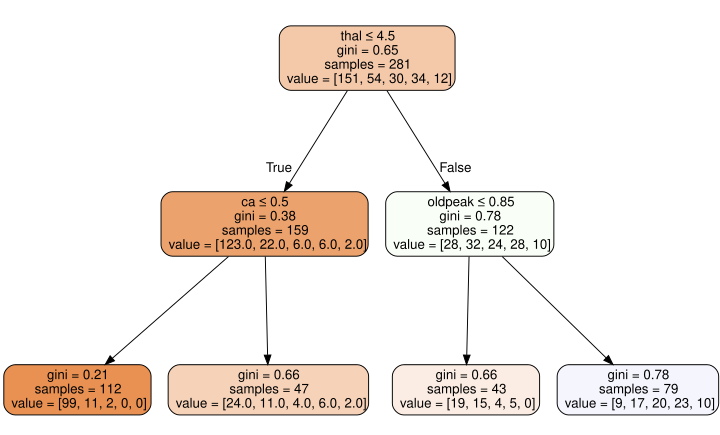

In [22]:
fastbook.setup_book()
from fastbook import *
draw_tree(m, xs, size=10, leaves_parallel=True, precision=2)

Let's try a decision tree without any configuration, this defaults to splitting until all leaves are pure. I fully expect this to overfit horribly.

In [23]:
m = DecisionTreeClassifier()
m.fit(xs, y);

In [24]:
print(misclassified(m, xs, y))
print(misclassified(m, valid_xs, valid_y))

0.0
0.4090909090909091


While the training loss is very low, the validation is very high, as we predicted there is lot of overfitting here.

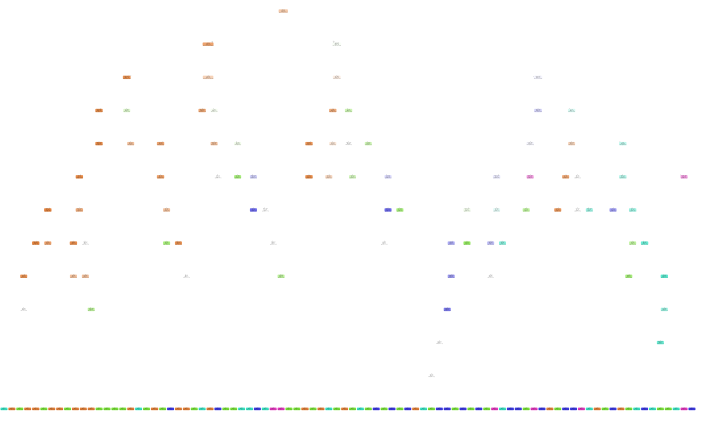

In [25]:

draw_tree(m, xs, size=10, leaves_parallel=True, precision=2)

In [26]:
import pandas as pd

n_nodes = m.tree_.node_count
children_left = m.tree_.children_left
children_right = m.tree_.children_right
values = m.tree_.value

# Find node IDs that are leaves (where both children are -1)
leaf_ids = [i for i in range(n_nodes) if children_left[i] == children_right[i]]

leaf_stats = []
for leaf in leaf_ids:
    leaf_stats.append({
        'Leaf ID': leaf,
        'Samples': m.tree_.n_node_samples[leaf],
        'Class Distribution': values[leaf][0]
    })

pd.DataFrame(leaf_stats)

,Leaf ID,Samples,Class Distribution
0,4,1,"[0.0, 0.0, 1.0, 0.0, 0.0]"
1,10,6,"[1.0, 0.0, 0.0, 0.0, 0.0]"
2,12,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"
3,13,1,"[1.0, 0.0, 0.0, 0.0, 0.0]"
4,14,71,"[1.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...
83,169,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"
84,170,1,"[0.0, 1.0, 0.0, 0.0, 0.0]"
85,171,7,"[0.0, 0.0, 1.0, 0.0, 0.0]"
86,173,2,"[0.0, 0.0, 0.0, 0.0, 1.0]"


Let's try random forests!

In [27]:
import numpy as np

def run_repeated_experiments(n_runs=10, state_offset=0,**kwargs):
    """
    Trains a Random Forest multiple times with varying random seeds 
    and prints the aggregated summary statistics.
    """
    print(f"Parameters: {kwargs}")
    print(f"Runs: {n_runs}")
    train_errors = []
    valid_errors = []
    oob_scores = []
    
    for i in range(n_runs):
        # Initialize model with a different random_state for each run
        m = RandomForestClassifier(
            n_jobs=-1, 
            **kwargs,
            oob_score=True,
            random_state=i + state_offset # Varies from 0 to n_runs-1
        )
        
        # Fit model
        m.fit(xs, y)
        
        # Calculate & Store Statistics
        train_errors.append(misclassified(m, xs, y))
        valid_errors.append(misclassified(m, valid_xs, valid_y))
        oob_scores.append(m.oob_score_)
        
    # Aggregate Summary Table
    stats = pd.DataFrame({
        'Metric': ['Train Misclassification', 'Valid Misclassification', 'OOB Score'],
        'Mean': [np.mean(train_errors), np.mean(valid_errors), np.mean(oob_scores)],
        'Std Dev': [np.std(train_errors), np.std(valid_errors), np.std(oob_scores)]
    })
    
    # Formatting for cleaner display
    stats['Mean'] = stats['Mean'].apply(lambda x: f"{x:.4f}")
    stats['Std Dev'] = stats['Std Dev'].apply(lambda x: f"± {x:.4f}")
    
    display(stats)
    
    return stats

Let's try tweaking the number of random forests

In [28]:
stats_1 = run_repeated_experiments(n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 10


,Metric,Mean,Std Dev
0,Train Misclassification,0.3153,± 0.0118
1,Valid Misclassification,0.4364,± 0.0302
2,OOB Score,0.5730,± 0.0102


In [29]:
stats_1 = run_repeated_experiments(n_estimators=100, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 100, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 10


,Metric,Mean,Std Dev
0,Train Misclassification,0.3181,± 0.0051
1,Valid Misclassification,0.4091,± 0.0352
2,OOB Score,0.5658,± 0.0099


In [30]:
stats_1 = run_repeated_experiments(n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 4, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 10


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

,Metric,Mean,Std Dev
0,Train Misclassification,0.3445,± 0.0212
1,Valid Misclassification,0.4273,± 0.0545
2,OOB Score,0.5530,± 0.0085


The training misclassification went up between 4 and 40, but not from 40 to 100.

The validation misclassification stays the same between 40 and 100, but paradoxically goes between going from 4 to 40.

The OOB score went up between 4 and 40, however, stayed the same as we scaled to 100.

Conclusion: 

40 -> 100 does not yield any quality benefits.

Validation misclassification has higher variance since it is smaller and hence we observe the abnormal result.

Let's repeat the same experiment with higher number of runs to see validation misclassification is a pattern or just noise.

In [31]:
stats_1 = run_repeated_experiments(n_runs=50, n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
stats_1 = run_repeated_experiments(n_runs=50, n_estimators=100, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
stats_1 = run_repeated_experiments(n_runs=50, n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 50


,Metric,Mean,Std Dev
0,Train Misclassification,0.3201,± 0.0124
1,Valid Misclassification,0.4355,± 0.0376
2,OOB Score,0.5740,± 0.0115


Parameters: {'n_estimators': 100, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 50


,Metric,Mean,Std Dev
0,Train Misclassification,0.3192,± 0.0103
1,Valid Misclassification,0.4336,± 0.0343
2,OOB Score,0.5736,± 0.0114


Parameters: {'n_estimators': 4, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 50


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

,Metric,Mean,Std Dev
0,Train Misclassification,0.3493,± 0.0197
1,Valid Misclassification,0.4400,± 0.0639
2,OOB Score,0.5490,± 0.0166


We note that the 4 tree random forests is still better in validation misclassification but note that it's variance is higher

It is also worse in OOB score and training misclassification.

Maybe it is the following cause:
a) The first 10 random_state are just, by chance, well suited for the 4 tree case and biasing the results.

We can see if (a) is the case by trying a different set of seeds and seeing that brings it up.

In [32]:
stats_1 = run_repeated_experiments(n_runs=10, state_offset=100, n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
stats_1 = run_repeated_experiments(n_runs=50, state_offset=100, n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Parameters: {'n_estimators': 4, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 10


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

,Metric,Mean,Std Dev
0,Train Misclassification,0.3473,± 0.0181
1,Valid Misclassification,0.4545,± 0.0575
2,OOB Score,0.5495,± 0.0196


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Parameters: {'n_estimators': 4, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Runs: 50


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

,Metric,Mean,Std Dev
0,Train Misclassification,0.3495,± 0.0159
1,Valid Misclassification,0.4582,± 0.0609
2,OOB Score,0.5485,± 0.0180


Nope it still seems to be winning on the validation misclasification. This might be something else. We will come back here later and try to improvise our model first.

How do we even improve this?
i) We know we cannot throw more forests.
ii) Would it be worth trying to split more - Let's try that

In [33]:
stats_1 = run_repeated_experiments(n_runs=50, state_offset=100, n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.05)


Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.05}
Runs: 50


,Metric,Mean,Std Dev
0,Train Misclassification,0.2215,± 0.0167
1,Valid Misclassification,0.4391,± 0.0432
2,OOB Score,0.5740,± 0.0153


Okay this is probably going in overfitting since validation error went up and OOB also went up, while training error went down.
This is probably not the knob to tweak.

In [34]:
stats_1 = run_repeated_experiments(n_runs=50, state_offset=100, n_estimators=40, max_samples=0.75, max_features=0.3, min_samples_split=0.1)


Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.3, 'min_samples_split': 0.1}
Runs: 50


,Metric,Mean,Std Dev
0,Train Misclassification,0.3337,± 0.0121
1,Valid Misclassification,0.4445,± 0.0409
2,OOB Score,0.5789,± 0.0107


Okay. I am using a mix of OOB score and validation score when the validation set is too small. Let's instead use K-fold stratergy per evaluation. The tradeoff is:

Slower training loop but we have more variance in validation error. This directly gives more variance in our model selection stratergy.

In [35]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

def run_kfold_experiments(X, y, n_splits=5, n_runs=1, state_offset=0, **kwargs):
    """
    Trains Random Forest using K-Fold cross-validation across multiple runs.
    """
    print(f"Parameters: {kwargs}")
    print(f"Strategy: {n_splits}-Fold CV | Runs: {n_runs}")
    
    val_errors = []
    oob_scores = []
    
    for run in range(n_runs):
        # Initialize KFold with a seed that changes per run
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=run + state_offset)
        
        run_errors = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            # Split using iloc for pandas compatibility
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Initialize model
            m = RandomForestClassifier(
                n_jobs=-1, 
                oob_score=True,
                random_state=run + state_offset,
                **kwargs
            )
            
            # Fit and record metrics
            m.fit(X_train, y_train)
            
            # Calculate validation error (1 - Accuracy)
            val_error = 1 - m.score(X_val, y_val)
            run_errors.append(val_error)
            oob_scores.append(m.oob_score_)
            
        val_errors.extend(run_errors)
        print(f"Run {run + 1} complete. Avg Error: {np.mean(run_errors):.4f}")

    # Final Aggregated Statistics
    print("-" * 30)
    print(f"Final Mean Validation Error: {np.mean(val_errors):.4f}")
    print(f"Final Mean OOB Score:        {np.mean(oob_scores):.4f}")
    print(f"Error Standard Deviation:    {np.std(val_errors):.4f}")
    
    return val_errors, oob_scores

In [36]:
# Concatenate X_train and X_val
X_full = pd.concat([xs, valid_xs], axis=0).reset_index(drop=True)
y_full = pd.concat([y, valid_y], axis=0).reset_index(drop=True)

Rerunning our first experiments with k-fold.

In [37]:
run_kfold_experiments(X_full, y_full, n_runs=10, n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
run_kfold_experiments(X_full, y_full, n_runs=10, n_estimators=100, max_samples=0.75, max_features=0.5, min_samples_split=0.1)
run_kfold_experiments(X_full, y_full, n_runs=10, n_estimators=4, max_samples=0.75, max_features=0.5, min_samples_split=0.1)


Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Strategy: 5-Fold CV | Runs: 10
Run 1 complete. Avg Error: 0.4359
Run 2 complete. Avg Error: 0.4227
Run 3 complete. Avg Error: 0.4322
Run 4 complete. Avg Error: 0.4093
Run 5 complete. Avg Error: 0.4291
Run 6 complete. Avg Error: 0.4523
Run 7 complete. Avg Error: 0.4353
Run 8 complete. Avg Error: 0.4326
Run 9 complete. Avg Error: 0.4226
Run 10 complete. Avg Error: 0.4259
------------------------------
Final Mean Validation Error: 0.4298
Final Mean OOB Score:        0.5753
Error Standard Deviation:    0.0510
Parameters: {'n_estimators': 100, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Strategy: 5-Fold CV | Runs: 10
Run 1 complete. Avg Error: 0.4293
Run 2 complete. Avg Error: 0.4360
Run 3 complete. Avg Error: 0.4289
Run 4 complete. Avg Error: 0.4160
Run 5 complete. Avg Error: 0.4323
Run 6 complete. Avg Error: 0.4490
Run 7 complete. Avg Error: 0.4223
Run 8 complete. A

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

Run 1 complete. Avg Error: 0.4128


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

Run 2 complete. Avg Error: 0.4293


...

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

Run 7 complete. Avg Error: 0.4353
Run 8 complete. Avg Error: 0.4656


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

Run 9 complete. Avg Error: 0.4291
Run 10 complete. Avg Error: 0.4327
------------------------------
Final Mean Validation Error: 0.4328
Final Mean OOB Score:        0.5428
Error Standard Deviation:    0.0559


([0.3770491803278688,
  0.34426229508196726,
  0.42622950819672134,
  0.43333333333333335,
  0.4833333333333333,
  0.4098360655737705,
  0.4098360655737705,
  0.39344262295081966,
  0.4,
  0.5333333333333333,
  0.42622950819672134,
  0.29508196721311475,
  0.4918032786885246,
  0.41666666666666663,
  0.4833333333333333,
  0.3770491803278688,
  0.4426229508196722,
  0.42622950819672134,
  0.41666666666666663,
  0.4666666666666667,
  0.360655737704918,
  0.42622950819672134,
  0.4426229508196722,
  0.44999999999999996,
  0.41666666666666663,
  0.4918032786885246,
  0.3770491803278688,
  0.42622950819672134,
  0.55,
  0.43333333333333335,
  0.4426229508196722,
  0.4426229508196722,
  0.5245901639344263,
  0.3833333333333333,
  0.3833333333333333,
  0.4426229508196722,
  0.5245901639344263,
  0.360655737704918,
  0.4666666666666667,
  0.5333333333333333,
  0.360655737704918,
  0.4098360655737705,
  0.4918032786885246,
  0.44999999999999996,
  0.43333333333333335,
  0.39344262295081966,
  0

Finally we can see a pattern that we expect emerging. The average valdation loss is lower for more trees.


Let's try to understand the features
a) Plot the most important feature.




In [42]:
 m = RandomForestClassifier(
            n_jobs=-1,
     n_estimators=40,
     max_samples=0.75,
     max_features=0.5, 
     min_samples_split=0.1,
            oob_score=True,
        )

m.fit(X_full, y_full)
def rf_feat_importance(m, df):
    return pd.DataFrame({'cols':df.columns, 'imp':m.feature_importances_}
                       ).sort_values('imp', ascending=False)

fi = rf_feat_importance(m, X_full)
fi[:13]

,cols,imp
14,thal,0.266120
1,cp,0.168790
13,ca,0.151062
12,oldpeak,0.103402
11,thalach,0.078143
4,exang,0.054356
9,trestbps,0.050738
8,age,0.042171
10,chol,0.041722
5,slope,0.020520


Let's maybe keep the first 5 and see if that helps our model



In [58]:

top_5_features = ['thal', 'cp', 'ca', 'oldpeak', 'thalach']

# Create the subset
X_subset = X_full[top_5_features]

# 3. Run the experiment
run_kfold_experiments(X_subset, y_full, n_splits=5, n_runs=10, n_estimators=40, max_samples=0.75, max_features=0.5, min_samples_split=0.1)

Parameters: {'n_estimators': 40, 'max_samples': 0.75, 'max_features': 0.5, 'min_samples_split': 0.1}
Strategy: 5-Fold CV | Runs: 10
Run 1 complete. Avg Error: 0.4260
Run 2 complete. Avg Error: 0.4062
Run 3 complete. Avg Error: 0.4190
Run 4 complete. Avg Error: 0.4092
Run 5 complete. Avg Error: 0.4292
Run 6 complete. Avg Error: 0.4227
Run 7 complete. Avg Error: 0.4254
Run 8 complete. Avg Error: 0.4195
Run 9 complete. Avg Error: 0.4425
Run 10 complete. Avg Error: 0.4261
------------------------------
Final Mean Validation Error: 0.4226
Final Mean OOB Score:        0.5775
Error Standard Deviation:    0.0546


([0.360655737704918,
  0.4426229508196722,
  0.4098360655737705,
  0.4666666666666667,
  0.44999999999999996,
  0.3770491803278688,
  0.42622950819672134,
  0.3278688524590164,
  0.41666666666666663,
  0.4833333333333333,
  0.4590163934426229,
  0.34426229508196726,
  0.5081967213114754,
  0.33333333333333337,
  0.44999999999999996,
  0.39344262295081966,
  0.4590163934426229,
  0.39344262295081966,
  0.3666666666666667,
  0.43333333333333335,
  0.360655737704918,
  0.39344262295081966,
  0.47540983606557374,
  0.4833333333333333,
  0.43333333333333335,
  0.4098360655737705,
  0.3770491803278688,
  0.39344262295081966,
  0.4833333333333333,
  0.44999999999999996,
  0.4426229508196722,
  0.5081967213114754,
  0.42622950819672134,
  0.35,
  0.4,
  0.4098360655737705,
  0.4426229508196722,
  0.3114754098360656,
  0.4666666666666667,
  0.4666666666666667,
  0.39344262295081966,
  0.3278688524590164,
  0.5245901639344263,
  0.5,
  0.4666666666666667,
  0.39344262295081966,
  0.4590163934426

Model is just as good but not better.


We might just need more data, try different model